In [1]:
#importing 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load cleaned data
df = pd.read_csv('Cleaned_datasets/final_merged_burnout_oecd.csv')

print("Data loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Data loaded!
Shape: (3000, 37)
Columns: ['employee_id', 'age', 'gender', 'country', 'job_role', 'department', 'years_at_company', 'work_hours_per_week', 'remote_work', 'burnout_level', 'job_satisfaction', 'stress_level', 'productivity_score', 'sleep_hours', 'physical_activity_hrs', 'commute_time', 'has_mental_health_support', 'manager_support_score', 'has_therapy_access', 'mental_health_days_off', 'salary_range', 'work_life_balance_score', 'team_size', 'career_growth_score', 'burnout_risk', 'high_burnout', 'overworked', 'age_group', 'air_pollution', 'employees_working_very_long_hours', 'employment_rate', 'life_expectancy', 'life_satisfaction', 'long_term_unemployment_rate', 'self_reported_health', 'time_devoted_to_leisure_and_personal_care', 'water_quality']


In [2]:
# imp features for ML
features = [
    'age', 'years_at_company', 'work_hours_per_week',
    'job_satisfaction', 'stress_level', 'productivity_score',
    'sleep_hours', 'physical_activity_hrs', 'commute_time',
    'manager_support_score', 'mental_health_days_off',
    'work_life_balance_score', 'team_size', 'career_growth_score'
]

# Target variable 
target = 'burnout_risk'

# Select only needed columns
ml_df = df[features + [target]].copy()

# Check for missing values
print("Missing values:")
print(ml_df.isnull().sum())
print("\nShape:", ml_df.shape)
print("\nTarget distribution:")
print(ml_df[target].value_counts())

Missing values:
age                        0
years_at_company           0
work_hours_per_week        0
job_satisfaction           0
stress_level               0
productivity_score         0
sleep_hours                0
physical_activity_hrs      0
commute_time               0
manager_support_score      0
mental_health_days_off     0
work_life_balance_score    0
team_size                  0
career_growth_score        0
burnout_risk               0
dtype: int64

Shape: (3000, 15)

Target distribution:
burnout_risk
0    2020
1     980
Name: count, dtype: int64


In [3]:
# Separate features and target
X = ml_df[features]
y = ml_df[target]

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducibility
    stratify=y          # keep same ratio of 0/1 in both splits
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())

Training set size: (2400, 14)
Testing set size: (600, 14)

Training target distribution:
burnout_risk
0    1616
1     784
Name: count, dtype: int64


LOGISTIC REGRESSION RESULTS

Accuracy: 67.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       404
           1       0.00      0.00      0.00       196

    accuracy                           0.67       600
   macro avg       0.34      0.50      0.40       600
weighted avg       0.45      0.67      0.54       600



C:\Users\gauri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gauri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gauri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


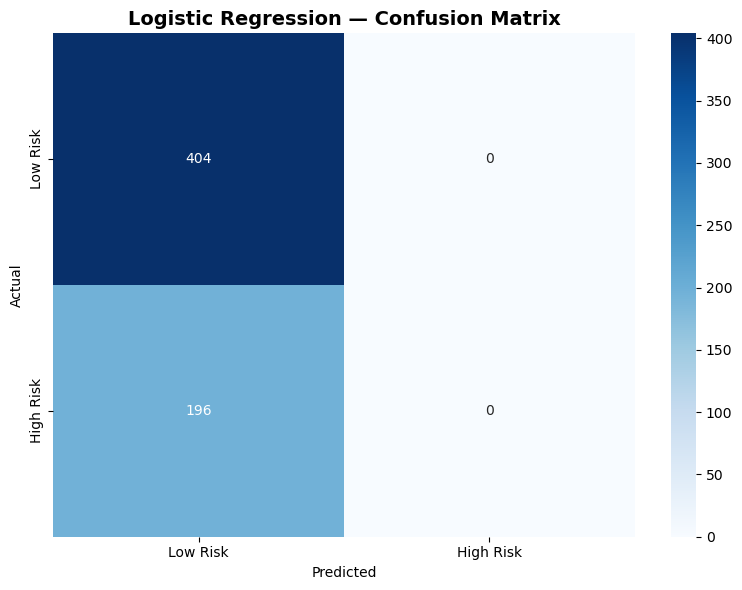

In [4]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

# Results
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"\nAccuracy: {accuracy_score(y_test, lr_predictions):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Logistic Regression — Confusion Matrix', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

RANDOM FOREST RESULTS

Accuracy: 67.17%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       404
           1       0.00      0.00      0.00       196

    accuracy                           0.67       600
   macro avg       0.34      0.50      0.40       600
weighted avg       0.45      0.67      0.54       600



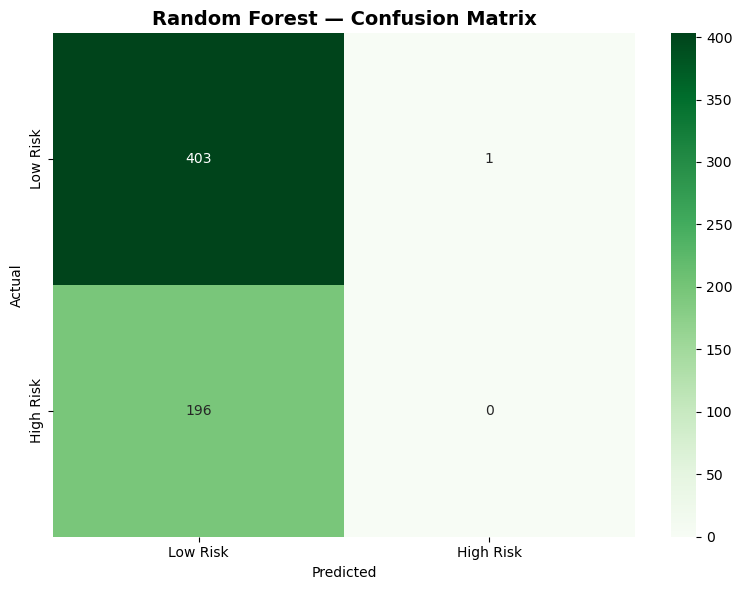

In [5]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42,
    max_depth=10        # prevent overfitting
)
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Results
print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"\nAccuracy: {accuracy_score(y_test, rf_predictions):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Random Forest — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

FEATURE IMPORTANCE — What Causes Burnout?
                    feature  importance
9     manager_support_score    0.091136
13      career_growth_score    0.083819
3          job_satisfaction    0.083626
5        productivity_score    0.083014
4              stress_level    0.081776
11  work_life_balance_score    0.081689
7     physical_activity_hrs    0.076047
8              commute_time    0.075669
12                team_size    0.067803
6               sleep_hours    0.067089
0                       age    0.057962
2       work_hours_per_week    0.057052
1          years_at_company    0.052434
10   mental_health_days_off    0.040884


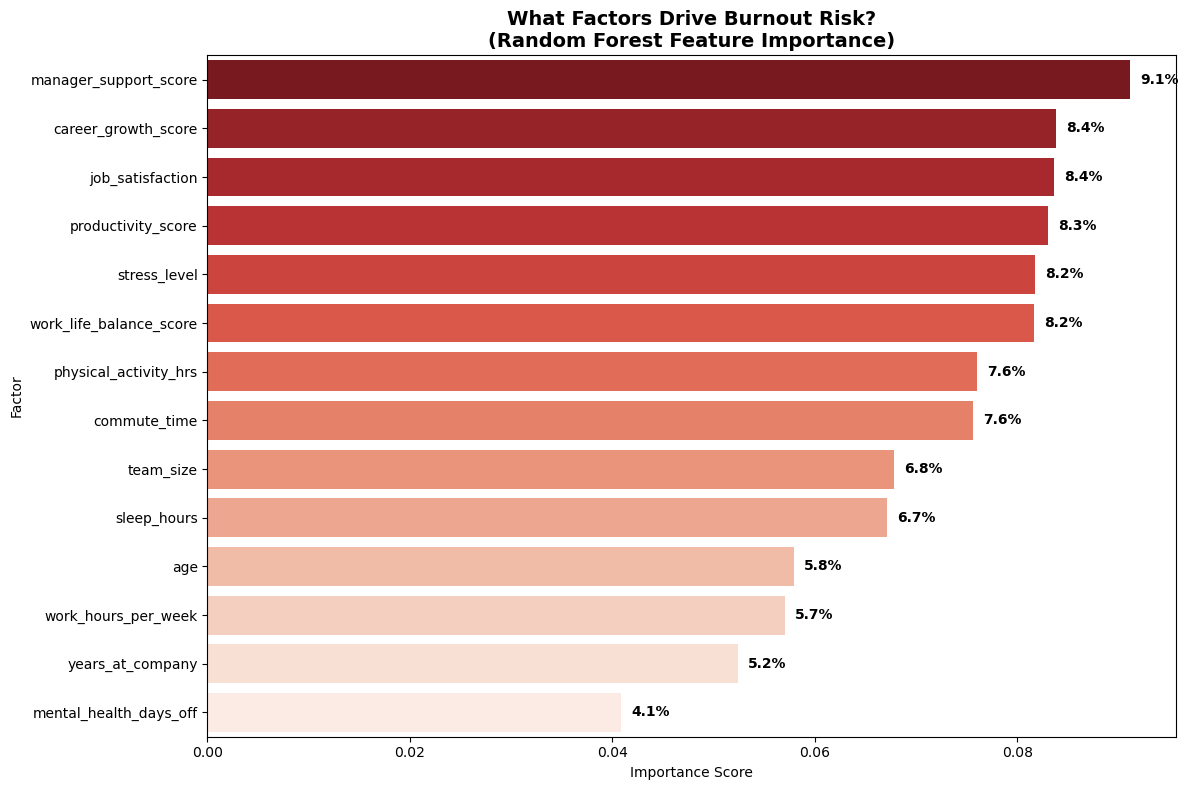

In [6]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=" * 50)
print("FEATURE IMPORTANCE — What Causes Burnout?")
print("=" * 50)
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance, 
            x='importance', y='feature',
            palette='Reds_r', hue='feature', legend=False)

# Add percentage labels
for i, v in enumerate(feature_importance['importance']):
    plt.text(v + 0.001, i, f'{v:.1%}', va='center', fontweight='bold')

plt.title('What Factors Drive Burnout Risk?\n(Random Forest Feature Importance)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Factor')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

MODEL COMPARISON SUMMARY
                 Model Accuracy
0  Logistic Regression   67.33%
1        Random Forest   67.17%


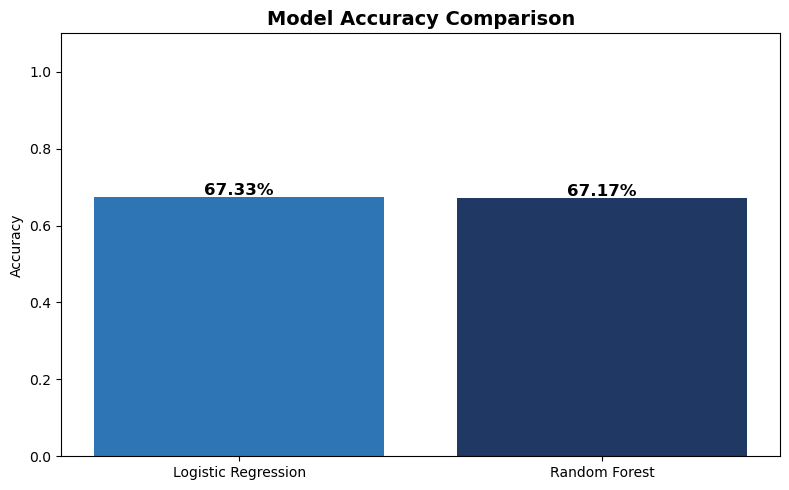

In [7]:
# Compare both models
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions)
    ]
})

comparison['Accuracy'] = comparison['Accuracy'].apply(lambda x: f'{x:.2%}')
print(comparison)

# Bar chart comparison
accuracies = [
    accuracy_score(y_test, lr_predictions),
    accuracy_score(y_test, rf_predictions)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(['Logistic Regression', 'Random Forest'], 
                accuracies, color=['#2E75B6', '#1F3864'])
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold', fontsize=12)

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [8]:
print("=" * 60)
print("KEY ML INSIGHTS FOR REPORT")
print("=" * 60)

print(f"""
1. BURNOUT PREDICTION ACCURACY:
   • Logistic Regression: {accuracy_score(y_test, lr_predictions):.2%}
   • Random Forest: {accuracy_score(y_test, rf_predictions):.2%}

2. TOP 5 FACTORS CAUSING BURNOUT:
{feature_importance.head(5).to_string(index=False)}

3. KEY FINDING:
   The most important factor driving burnout risk is:
   '{feature_importance.iloc[0]['feature']}' 
   with {feature_importance.iloc[0]['importance']:.1%} importance

4. BUSINESS RECOMMENDATION:
   Organizations should focus on improving 
   '{feature_importance.iloc[0]['feature']}' and 
   '{feature_importance.iloc[1]['feature']}' 
   to significantly reduce employee burnout risk.
""")

KEY ML INSIGHTS FOR REPORT

1. BURNOUT PREDICTION ACCURACY:
   • Logistic Regression: 67.33%
   • Random Forest: 67.17%

2. TOP 5 FACTORS CAUSING BURNOUT:
              feature  importance
manager_support_score    0.091136
  career_growth_score    0.083819
     job_satisfaction    0.083626
   productivity_score    0.083014
         stress_level    0.081776

3. KEY FINDING:
   The most important factor driving burnout risk is:
   'manager_support_score' 
   with 9.1% importance

4. BUSINESS RECOMMENDATION:
   Organizations should focus on improving 
   'manager_support_score' and 
   'career_growth_score' 
   to significantly reduce employee burnout risk.

